# Bikeablity testing

Using this cell to read in some results for one place/scenario at a time, and investigate the different ways of computing bikeablity, along with a few sanity checks. I'm being lazy and reading the results from hard-coded file paths, so you'll need to adjust these.

## Setup

In [ ]:
import pickle
import os
import glob
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd

## Sanity checks 

We load the first result of the "demand" growth order, as it is the most important result for sanity checking. This is because it should have selected the connection to make with the highest possible demand at that stage. We save as geopackages to use in QGIS or similar.

Saved: H:\Other\first_demand_full.gpkg
Saved: H:\Other\first_demand_abstract.gpkg


<Axes: >

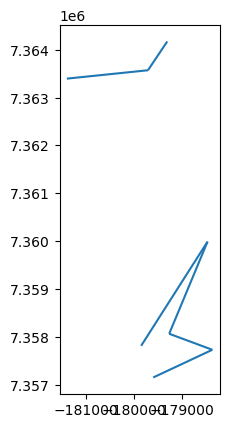

In [2]:
pickle_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario\newcastle_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"

with open(pickle_path, "rb") as f:
    data = pickle.load(f)

G_full = data["GTs"][1]
G_abs  = data["GT_abstracts"][1]

# Fix missing CRS in abstract graph
if "crs" not in G_abs.graph:
    G_abs.graph["crs"] = "EPSG:3857"

# Convert both graphs
nodes_full, edges_full = ox.graph_to_gdfs(G_full)
nodes_abs,  edges_abs  = ox.graph_to_gdfs(G_abs)

# Output paths
out_full = r"H:\Other\first_demand_full.gpkg"
out_abs  = r"H:\Other\first_demand_abstract.gpkg"


# Save full graph
nodes_full.to_file(out_full, layer="nodes", driver="GPKG")
edges_full.to_file(out_full, layer="edges", driver="GPKG")

# Save abstract graph
nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
edges_abs.to_file(out_abs, layer="edges", driver="GPKG")

print("Saved:", out_full)
print("Saved:", out_abs)


edges_abs.plot()

- we can also get first iteration from the the random results to look at in QGIS or similar...

In [3]:
input_folder = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario"

# Folder where you want to save the GeoPackages
output_folder = r"H:\Other"



pattern = os.path.join(input_folder, "newcastle_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
files = sorted(glob.glob(pattern))
print(f"Found {len(files)} files")

# for fpath in files:
#     # Extract run number from filename
#     fname = os.path.basename(fpath)
#     run_id = fname.split("_run")[-1].split(".")[0]   # e.g. "00", "01", ...

#     print(f"Processing run {run_id}...")

#     # Load pickle
#     with open(fpath, "rb") as f:
#         data = pickle.load(f)

#     # Extract graphs
#     G_full = data["GTs"][1]            # or [0] if you want the first
#     G_abs  = data["GT_abstracts"][1]   # or [0]

#     # Fix missing CRS in abstract graph
#     if "crs" not in G_abs.graph:
#         G_abs.graph["crs"] = "EPSG:3857"

#     # Convert to GeoDataFrames
#     nodes_full, edges_full = ox.graph_to_gdfs(G_full)
#     nodes_abs,  edges_abs  = ox.graph_to_gdfs(G_abs)

#     # Output paths
#     out_full = os.path.join(output_folder, f"random_run{run_id}_full.gpkg")
#     out_abs  = os.path.join(output_folder, f"random_run{run_id}_abstract.gpkg")

#     # Save full graph
#     nodes_full.to_file(out_full, layer="nodes", driver="GPKG")
#     edges_full.to_file(out_full, layer="edges", driver="GPKG")

#     # Save abstract graph
#     nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
#     edges_abs.to_file(out_abs, layer="edges", driver="GPKG")

#     print(f"Saved run {run_id} to:")
#     print("  ", out_full)
#     print("  ", out_abs)

print("All runs processed.")


Found 100 files
All runs processed.


- we access the demand OD matrix which out trips are based on. the "total_flow" column is the number of trips

In [4]:
gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\newcastle\current_ltn_scenario\newcastle_current_ltn_scenario_greedy_demand_weighted.gpkg"
mydemand = gpd.read_file(gpkg_path)
mydemand.head()

,start_osmid,end_osmid,distance,sp_lts_route,sp_lts_distance,sp_true_distance,eucl_dist,ltn_origin,ltn_destination,start_norm,end_norm,osmid_pair,sp_lts_route_str,total_flow,geometry
0,826287045,1948868613,309.249812,None,2053.724,426.113,309.249812,True,True,826287045,1948868613,None,"[826287045, 619516312, 10695413661, 1244973279...",15.051057,"LINESTRING (-1.62488 54.96771, -1.62136 54.96961)"
1,12251671069,4140896891,366.611193,None,5312.233,1130.746,366.611193,True,True,4140896891,12251671069,None,"[12251671069, 12251671068, 12091933084, 120919...",18.730863,"LINESTRING (-1.61558 54.97912, -1.61032 54.98041)"
2,2392633844,12251671069,406.684872,None,4948.051,1312.318,406.684872,True,True,2392633844,12251671069,None,"[2392633844, 6892581625, 4033856209, 124741218...",15.049021,"LINESTRING (-1.61332 54.97571, -1.61558 54.97912)"
3,29013257,252100827,415.313673,None,4646.445,1326.051,415.313673,True,True,29013257,252100827,None,"[29013257, 60150990, 2858920421, 29013256, 285...",34.732309,"LINESTRING (-1.61430 55.00879, -1.61068 55.01189)"
4,776327170,345643357,481.877848,None,1352.248,676.124,481.877848,True,True,345643357,776327170,None,"[776327170, 776327214, 776327226, 4634363980, ...",29.910114,"LINESTRING (-1.58216 54.97811, -1.58948 54.97912)"


- map the demand from mydemand onto the abstract edges we have from above to check what sort of number of trips to expect.

In [5]:
# Create a merge key in both tables
mydemand["edge_id"] = mydemand.apply(lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)
edges_abs = edges_abs.reset_index()  # bring u, v, key into columns
edges_abs["edge_id"] = edges_abs.apply(lambda r: tuple(sorted((r.u, r.v))), axis=1)

# Merge total_flow onto edges_abs 
edges_abs = edges_abs.merge(mydemand[["edge_id", "total_flow"]], on="edge_id",how="left")

# edges_abs now contains a new column: total_flow
edges_abs.head()

# print how many trips we've got just on the first iteration
total_flow_sum = edges_abs["total_flow"].sum()
total_flow_sum

325.6993904707022

## Super simple bikeablity

The first way to try measureing bikeablity is to just measure each link's number of trips as it gets added. This doesn't consider that other routes might be available, or that some trips could already be done just fine. It does however work as a sanity check to see that the demand approach is 100% better than any random run. 

This first cell just does the first run from demand and random (you can skip this)

Loading reference demand data...
Processing DEMAND scenario...
  > Demand Flow: 326, Length: 9420
Found 100 random run files.
Processing Random Run 00...
Processing Random Run 01...
Processing Random Run 02...
Processing Random Run 03...
Processing Random Run 04...
Processing Random Run 05...
Processing Random Run 06...
Processing Random Run 07...
Processing Random Run 08...
Processing Random Run 09...
Processing Random Run 10...
Processing Random Run 11...
Processing Random Run 12...
Processing Random Run 13...
Processing Random Run 14...
Processing Random Run 15...
Processing Random Run 16...
Processing Random Run 17...
Processing Random Run 18...
Processing Random Run 19...
Processing Random Run 20...
Processing Random Run 21...
Processing Random Run 22...
Processing Random Run 23...
Processing Random Run 24...
Processing Random Run 25...
Processing Random Run 26...
Processing Random Run 27...
Processing Random Run 28...
Processing Random Run 29...
Processing Random Run 30...
Proces

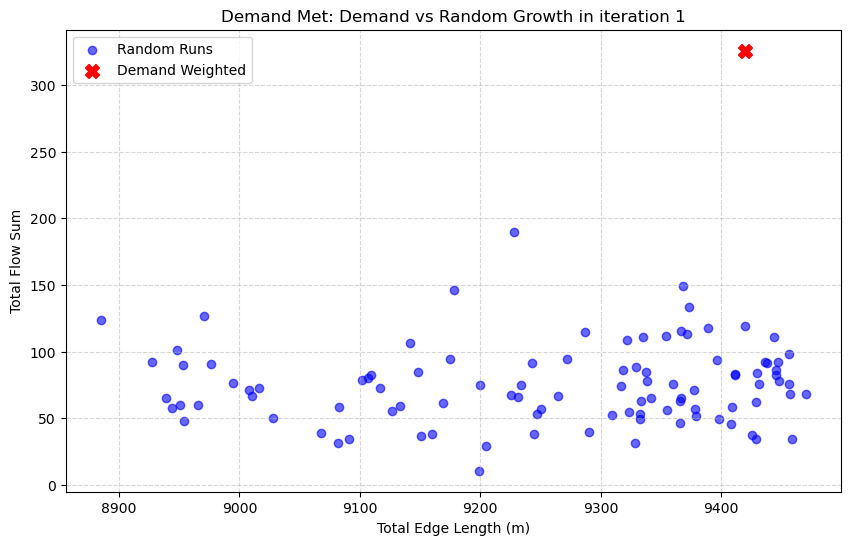

In [6]:
# Path to the reference demand GPKG (contains 'total_flow' per edge)
ref_gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\newcastle\current_ltn_scenario\newcastle_current_ltn_scenario_greedy_demand_weighted.gpkg"
print("Loading reference demand data...")
mydemand = gpd.read_file(ref_gpkg_path)

# Create merge key 
mydemand["edge_id"] = mydemand.apply(lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)
# Keep only what we need for merging to speed things up
reference_flow = mydemand[["edge_id", "total_flow"]]

# Output folder for GPKGs
output_folder = r"H:\Other"

# Lists to store plot data
plot_data = {
    "demand": {"flow": 0, "length": 0},
    "random": {"flow": [], "length": []}
}

def process_edges(edges_gdf, ref_df):
    """Helper to merge flow and calc stats"""
    edges_gdf = edges_gdf.copy()
    edges_gdf = edges_gdf.reset_index()
    edges_gdf["edge_id"] = edges_gdf.apply(lambda r: tuple(sorted((r.u, r.v))), axis=1)
    merged = edges_gdf.merge(ref_df, on="edge_id", how="left")
    total_len = merged.length.sum()
    total_flow = merged["total_flow"].sum()
    
    return total_len, total_flow


demand_pickle_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario\newcastle_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"
print(f"Processing DEMAND scenario...")
with open(demand_pickle_path, "rb") as f:
    data = pickle.load(f)
G_abs = data["GT_abstracts"][1]
if "crs" not in G_abs.graph: G_abs.graph["crs"] = "EPSG:3857"
nodes_abs, edges_abs = ox.graph_to_gdfs(G_abs)

# save for inspection 
out_abs = os.path.join(output_folder, "first_demand_abstract.gpkg")
nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
edges_abs.to_file(out_abs, layer="edges", driver="GPKG")

# CALCULATE STATS
d_len, d_flow = process_edges(edges_abs, reference_flow)
plot_data["demand"]["length"] = d_len
plot_data["demand"]["flow"] = d_flow
print(f"  > Demand Flow: {d_flow:.0f}, Length: {d_len:.0f}")





input_folder = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario"
pattern = os.path.join(input_folder, "newcastle_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
files = sorted(glob.glob(pattern))
print(f"Found {len(files)} random run files.")

for fpath in files:
    fname = os.path.basename(fpath)
    run_id = fname.split("_run")[-1].split(".")[0]
    print(f"Processing Random Run {run_id}...")
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    G_abs = data["GT_abstracts"][1]
    if "crs" not in G_abs.graph: G_abs.graph["crs"] = "EPSG:3857"
    nodes_abs, edges_abs = ox.graph_to_gdfs(G_abs)
    
    # save for inspection
    out_abs = os.path.join(output_folder, f"random_run{run_id}_abstract.gpkg")
    nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
    edges_abs.to_file(out_abs, layer="edges", driver="GPKG")
    
    # calcaulate stats
    r_len, r_flow = process_edges(edges_abs, reference_flow)
    plot_data["random"]["length"].append(r_len)
    plot_data["random"]["flow"].append(r_flow)

# plot
plt.figure(figsize=(10, 6))
plt.scatter(plot_data["random"]["length"], plot_data["random"]["flow"], 
            color='blue', alpha=0.6, label='Random Runs')
plt.scatter(plot_data["demand"]["length"], plot_data["demand"]["flow"], 
            color='red', s=100, marker='X', label='Demand Weighted', zorder=5)
plt.xlabel('Total Edge Length (m)')
plt.ylabel('Total Flow Sum')
plt.title('Demand Met: Demand vs Random Growth in iteration 1')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- we can do the same but this time for the 2nd iteration just to check:

Loading reference demand data...
Processing DEMAND scenario...
  > Demand Flow: 418, Length: 14181
Found 100 random run files.
Processing Random Run 00...
Processing Random Run 01...
Processing Random Run 02...
Processing Random Run 03...
Processing Random Run 04...
Processing Random Run 05...
Processing Random Run 06...
Processing Random Run 07...
Processing Random Run 08...
Processing Random Run 09...
Processing Random Run 10...
Processing Random Run 11...
Processing Random Run 12...
Processing Random Run 13...
Processing Random Run 14...
Processing Random Run 15...
Processing Random Run 16...
Processing Random Run 17...
Processing Random Run 18...
Processing Random Run 19...
Processing Random Run 20...
Processing Random Run 21...
Processing Random Run 22...
Processing Random Run 23...
Processing Random Run 24...
Processing Random Run 25...
Processing Random Run 26...
Processing Random Run 27...
Processing Random Run 28...
Processing Random Run 29...
Processing Random Run 30...
Proce

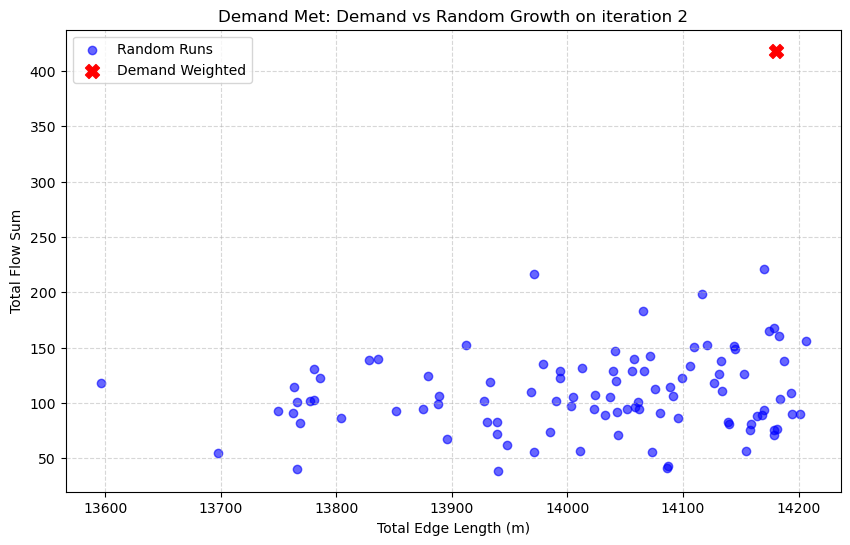

In [ ]:
# Path to the reference demand GPKG (contains 'total_flow' per edge)
ref_gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\newcastle\current_ltn_scenario\newcastle_current_ltn_scenario_greedy_demand_weighted.gpkg"
print("Loading reference demand data...")
mydemand = gpd.read_file(ref_gpkg_path)


mydemand["edge_id"] = mydemand.apply(
    lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)

reference_flow = mydemand[["edge_id", "total_flow"]]
output_folder = r"H:\Other"

plot_data = {
    "demand": {"flow": 0, "length": 0},
    "random": {"flow": [], "length": []}}

def process_edges(edges_gdf, ref_df):
    """Helper to merge flow and calc stats"""
    edges_gdf = edges_gdf.copy()
    edges_gdf = edges_gdf.reset_index()
    edges_gdf["edge_id"] = edges_gdf.apply(
        lambda r: tuple(sorted((r.u, r.v))), axis=1)
    merged = edges_gdf.merge(ref_df, on="edge_id", how="left")
    total_len = merged.length.sum()
    total_flow = merged["total_flow"].sum()
    return total_len, total_flow


demand_pickle_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario\newcastle_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"
print(f"Processing DEMAND scenario...")
with open(demand_pickle_path, "rb") as f:
    data = pickle.load(f)
G_abs = data["GT_abstracts"][2]
if "crs" not in G_abs.graph: G_abs.graph["crs"] = "EPSG:3857"
nodes_abs, edges_abs = ox.graph_to_gdfs(G_abs)

# SAVE 
out_abs = os.path.join(output_folder, "first_demand_abstract.gpkg")
nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
edges_abs.to_file(out_abs, layer="edges", driver="GPKG")

# CALCULATE STATS
d_len, d_flow = process_edges(edges_abs, reference_flow)
plot_data["demand"]["length"] = d_len
plot_data["demand"]["flow"] = d_flow
print(f"  > Demand Flow: {d_flow:.0f}, Length: {d_len:.0f}")

input_folder = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario"
pattern = os.path.join(input_folder, "newcastle_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
files = sorted(glob.glob(pattern))

print(f"Found {len(files)} random run files.")
for fpath in files:
    fname = os.path.basename(fpath)
    run_id = fname.split("_run")[-1].split(".")[0]
    print(f"Processing Random Run {run_id}...")
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    G_abs = data["GT_abstracts"][2]
    if "crs" not in G_abs.graph: G_abs.graph["crs"] = "EPSG:3857"
    nodes_abs, edges_abs = ox.graph_to_gdfs(G_abs)
    out_abs = os.path.join(output_folder, f"random_run{run_id}_abstract.gpkg")
    nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
    edges_abs.to_file(out_abs, layer="edges", driver="GPKG")
    r_len, r_flow = process_edges(edges_abs, reference_flow)
    plot_data["random"]["length"].append(r_len)
    plot_data["random"]["flow"].append(r_flow)


plt.figure(figsize=(10, 6))
plt.scatter(plot_data["random"]["length"], plot_data["random"]["flow"], 
            color='blue', alpha=0.6, label='Random Runs')

plt.scatter(plot_data["demand"]["length"], plot_data["demand"]["flow"], 
            color='red', s=100, marker='X', label='Demand Weighted', zorder=5)

plt.xlabel('Total Edge Length (m)')
plt.ylabel('Total Flow Sum')
plt.title('Demand Met: Demand vs Random Growth on iteration 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging\demand_vs_random_iteration_2.png", dpi=300, bbox_inches='tight')
plt.show()

- since those look good, we can start to plot more runs:

Loading reference demand data...
Finding demand met
Plotting results...


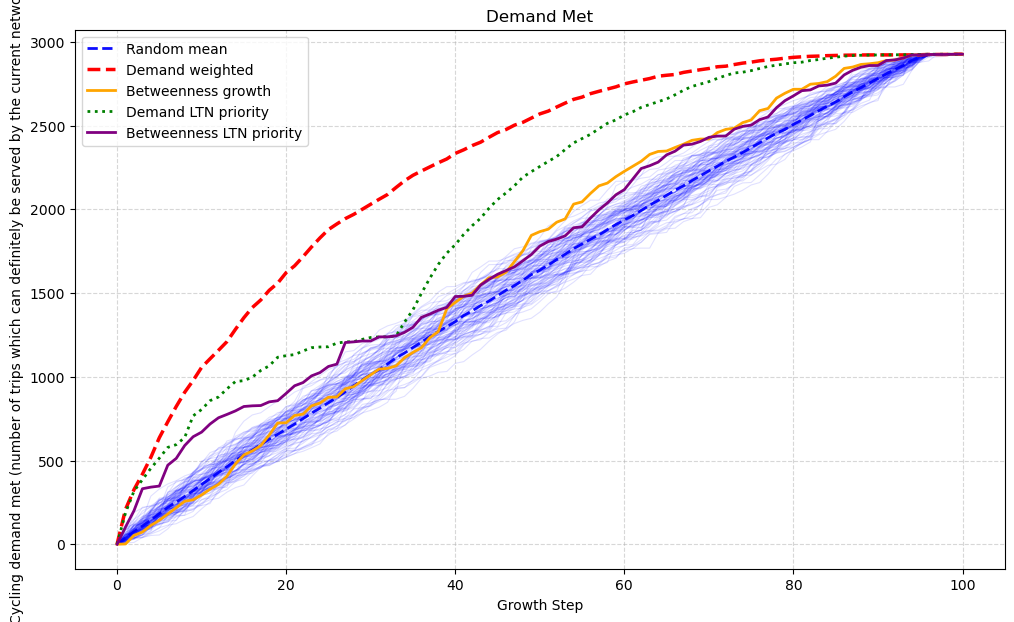

In [ ]:
#  Load Reference Demand
ref_gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\newcastle\current_ltn_scenario\newcastle_current_ltn_scenario_greedy_demand_weighted.gpkg"
print("Loading reference demand data...")
mydemand = gpd.read_file(ref_gpkg_path)

# Create the sorted edge_id tuple
mydemand["edge_id"] = mydemand.apply(lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)

trips_dict = dict(zip(mydemand["edge_id"], mydemand["total_flow"]))

NUM_STEPS = 100

plot_data = {
    "demand": [],        
    "random_runs": []    }


def get_demand_met_fast(G, trips_dict):
    if not G or not hasattr(G, 'edges'):
        return 0.0
    # 1. Extract all edges from the MultiDiGraph
    # 2. Sort the node pairs (min, max) so direction doesn't matter
    # 3. Use set() to drop duplicates (shouldn't be any anyway?)
    unique_edges = set(tuple(sorted((u, v))) for u, v in G.edges())
    
    return sum(trips_dict.get(edge, 0.0) for edge in unique_edges)

base_results_folder = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario"

results_files = {
    "betweenness_growth": os.path.join(base_results_folder, "newcastle_poi_LTNs_tessellation_betweenness_weighted_current_ltn_scenario.pickle"),
    "demand_ltn_priority": os.path.join(base_results_folder, "newcastle_poi_LTNs_tessellation_demand_ltn_priority_weighted_current_ltn_scenario.pickle"),
    "betweenness_ltn_priority": os.path.join(base_results_folder, "newcastle_poi_LTNs_tessellation_betweenness_ltn_priority_weighted_current_ltn_scenario.pickle"),}

def load_scenario_flows(pickle_path, trips_dict, steps):
    flows = [0.0] # Inject 0 for Stage 0 baseline
    with open(pickle_path, "rb") as fh:
        data = pickle.load(fh)
    graphs = data.get("GT_abstracts", [])
    for i in range(steps):
        if i >= len(graphs):
            break
        flows.append(get_demand_met_fast(graphs[i], trips_dict))
    return flows

print("Finding demand met")
results = {}
for name, path in results_files.items():
    if os.path.exists(path):
        results[name] = load_scenario_flows(path, trips_dict, NUM_STEPS)
    else:
        results[name] = [0.0]

# Load standard Demand
demand_pickle_path = os.path.join(base_results_folder, "newcastle_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle")
if os.path.exists(demand_pickle_path):
    plot_data["demand"].append(0.0) # Stage 0
    with open(demand_pickle_path, "rb") as fh:
        ddata = pickle.load(fh)
    dgraphs = ddata.get("GT_abstracts", [])
    for i in range(NUM_STEPS):
        if i >= len(dgraphs): break
        plot_data["demand"].append(get_demand_met_fast(dgraphs[i], trips_dict))

# Load Random Runs
random_pattern = os.path.join(base_results_folder, "newcastle_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
random_files = sorted(glob.glob(random_pattern))
for fpath in random_files: 
    with open(fpath, "rb") as fh:
        rdata = pickle.load(fh)
    rgraphs = rdata.get("GT_abstracts", [])
    run_flows = [0.0] # Stage 0
    for i in range(NUM_STEPS):
        if i >= len(rgraphs): break
        run_flows.append(get_demand_met_fast(rgraphs[i], trips_dict))
    plot_data["random_runs"].append(run_flows)

# Padding arrays to max length for plotting
max_len = max(
    len(plot_data["demand"]),
    max((len(r) for r in plot_data["random_runs"]), default=0),
    max((len(s) for s in results.values()), default=0)
)

def pad_to_len(seq, length, fill=np.nan):
    return list(seq) + [fill] * (length - len(seq))

demand_padded = pad_to_len(plot_data["demand"], max_len, fill=np.nan)
runs_padded = [pad_to_len(r, max_len, fill=np.nan) for r in plot_data["random_runs"]]
scenarios_padded = {k: pad_to_len(v, max_len, fill=np.nan) for k, v in results.items()}

arr = np.array(runs_padded, dtype=float) if runs_padded else np.empty((0, max_len))
random_mean = np.nanmean(arr, axis=0) if arr.size else np.full(max_len, np.nan)

# plot
print("Plotting results...")
plt.figure(figsize=(12, 7))
x_axis = np.arange(0, max_len) # Starts at 0 

# Random runs
for run_values in runs_padded:
    ys = np.array(run_values, dtype=float)
    mask = ~np.isnan(ys)
    if mask.sum() >= 2:
        plt.plot(x_axis[mask], ys[mask], color='blue', alpha=0.12, linewidth=0.8)

# Random Mean
if not np.all(np.isnan(random_mean)):
    plt.plot(x_axis, random_mean, color='blue', linestyle='--', alpha=0.95, linewidth=2.0, label='Random mean')

# Demand
dys = np.array(demand_padded, dtype=float)
mask_d = ~np.isnan(dys)
if mask_d.sum() >= 2:
    plt.plot(x_axis[mask_d], dys[mask_d], color='red', linestyle='--', linewidth=2.5, label='Demand weighted')

# Betweenness Growth
bg = np.array(scenarios_padded.get("betweenness_growth", []), dtype=float)
mask_bg = ~np.isnan(bg)
if mask_bg.sum() >= 2:
    plt.plot(x_axis[mask_bg], bg[mask_bg], color='orange', linestyle='-', linewidth=2.0, label='Betweenness growth')

# Demand LTN Priority
dlp = np.array(scenarios_padded.get("demand_ltn_priority", []), dtype=float)
mask_dlp = ~np.isnan(dlp)
if mask_dlp.sum() >= 2:
    plt.plot(x_axis[mask_dlp], dlp[mask_dlp], color='green', linestyle=':', linewidth=2.0, label='Demand LTN priority')

# Betweenness LTN Priority
blp = np.array(scenarios_padded.get("betweenness_ltn_priority", []), dtype=float)
mask_blp = ~np.isnan(blp)
if mask_blp.sum() >= 2:
    plt.plot(x_axis[mask_blp], blp[mask_blp], color='purple', linestyle='-', linewidth=2.0, label='Betweenness LTN priority')

plt.xlabel('Growth Step')
plt.ylabel('Cycling demand met (number of trips which can definitely be served by the current network)')
plt.title('Demand Met')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging\demand_met_over_growth.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# this should match the max value in the plot
mydemand['total_flow'].sum()

2926.488247762989

this looks good at the moment - we know that we are growing our networks correctly. 

# Checking through manually

This bit of code will make plots to see actually what is happening "on the ground" for each run, to work out why random results might do so well when we measure bikeablity on a network bigger than just the abstract connections.

In [15]:
# load the OD demand GPKG
od_gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\gateshead\current_ltn_scenario\gateshead_current_ltn_scenario_greedy_demand_weighted.gpkg"
od_demand = gpd.read_file(od_gpkg_path)

In [16]:
# load the base bikeable network
G_bikeable_edges = gpd.read_file(r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\gateshead\current_ltn_scenario\gateshead_biketrackcarall.gpkg", layer="edges")
G_bikeable_nodes = gpd.read_file(r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\gateshead\current_ltn_scenario\gateshead_biketrackcarall.gpkg", layer="nodes")
G_bikeable_edges = G_bikeable_edges.set_index(["u", "v", "key"])
G_bikeable_nodes = G_bikeable_nodes.set_index("osmid")
exit_points = gpd.read_file(r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\exports_gpkg\gateshead\current_ltn_scenario\gateshead_exit_points.gpkg")
G_bikeable_nx = ox.graph_from_gdfs(G_bikeable_nodes, G_bikeable_edges)

In [17]:
# load the LTNs (for visual help)
ltns = gpd.read_file(r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\gateshead\current_ltn_scenario\scored_neighbourhoods_gateshead.gpkg")

c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


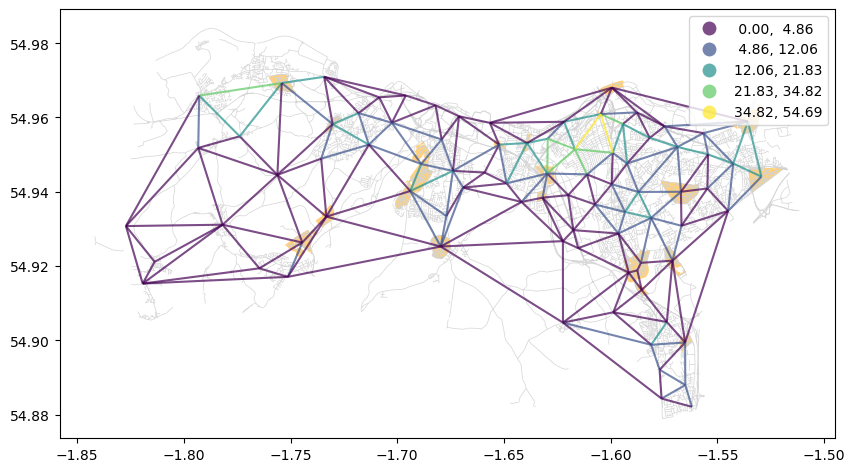

In [18]:
# have a look at our demand across the city
fig, ax = plt.subplots(figsize=(10, 10))
G_bikeable_edges.plot(ax=ax, color='lightgray', linewidth=0.5)
od_demand.plot(ax=ax, column='total_flow', legend=True, scheme="natural_breaks", markersize=50, alpha=0.7)
ltns.plot(ax=ax, alpha=0.5, color="orange")
plt.show()

In [19]:
# load some results
results_pickle_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\gateshead\current_ltn_scenario\gateshead_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"
with open(results_pickle_path, "rb") as f:
    results_data = pickle.load(f)

In [27]:
# Make sure edge_id exists as a sorted tuple
od_demand["edge_id"] = od_demand.apply(lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)
trips_dict = dict(zip(od_demand["edge_id"], od_demand["total_flow"]))


def get_demand_met_fast(G, trips_dict): # same as above
    if not G or not hasattr(G, 'edges'):
        return 0.0
    unique_edges = set(tuple(sorted((u, v))) for u, v in G.edges())
    return sum(trips_dict.get(edge, 0.0) for edge in unique_edges)


target_crs = "EPSG:4326"
od_demand = od_demand.to_crs(target_crs)
G_bikeable_edges = G_bikeable_edges.to_crs(target_crs)
ltns = ltns.to_crs(target_crs)
target_demand_total = od_demand['total_flow'].sum()



for i, (G_routed, G_abs) in enumerate(zip(results_data["GTs"], results_data["GT_abstracts"])):
    current_met_flow = get_demand_met_fast(G_abs, trips_dict)

    if "crs" not in G_routed.graph:
        G_routed.graph["crs"] = "EPSG:3857"
    if "crs" not in G_abs.graph:
        G_abs.graph["crs"] = "EPSG:3857"
        
    _, edges_routed = ox.graph_to_gdfs(G_routed)
    _, edges_abs = ox.graph_to_gdfs(G_abs)
    
    edges_routed = edges_routed.to_crs(target_crs)
    edges_abs = edges_abs.to_crs(target_crs)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    G_bikeable_edges.plot(ax=ax, color='lightgray', linewidth=0.5)
    od_demand.plot(ax=ax, column='total_flow', legend=False, scheme="natural_breaks", markersize=50, alpha=0.7)

    # Add Labels 
    for _, row in od_demand.iterrows():
        if row.geometry is not None:
            point = row.geometry.interpolate(0.5, normalized=True)
            ax.text(
                point.x, point.y,
                f"{row['total_flow']:.1f}",
                fontsize=5,
                ha='center',
                va='center',
                bbox=dict(facecolor='white', alpha=0.1, edgecolor='none', pad=1),
                clip_on=True
            )

    edges_routed.plot(ax=ax, color='blue', linewidth=1)
    edges_abs.plot(ax=ax, color='red', linewidth=2)
    ltns.plot(ax=ax, alpha=0.5, color="orange")

    # Zoom to AOI
    minx, miny, maxx, maxy = edges_routed.total_bounds
    pad_x = (maxx - minx) * 0.30
    pad_y = (maxy - miny) * 0.30

    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_autoscale_on(False)
    ax.set_axis_off()


    plt.title(f"Iteration {i} | Total Flow Met: {current_met_flow:.1f} of a target {target_demand_total:.1f} ({(current_met_flow/target_demand_total*100):.1f}%)")
    save_path = rf"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging\gateshead_step_{i}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    print(f"Saved Frame {i} | Flow Met: {current_met_flow:.1f}")

print("All frames rendered successfully!")

c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Saved Frame 0 | Flow Met: 119.5


c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Saved Frame 1 | Flow Met: 219.1


c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

Saved Frame 97 | Flow Met: 1445.2


c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Saved Frame 98 | Flow Met: 1445.2


c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Saved Frame 99 | Flow Met: 1445.2
All frames rendered successfully!


we can also plot the random results. This is set up to only make a plot if the demand met is greater than the demand met at the same point from the "demand" ordered data, so we can see what is going on at those points. Hopefully we get no plots...

In [ ]:
if "edge_id" not in od_demand.columns:
    od_demand["edge_id"] = od_demand.apply(lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)
trips_dict = dict(zip(od_demand["edge_id"], od_demand["total_flow"]))

def get_demand_met_fast(G, trips_dict):
    if not G or not hasattr(G, 'edges'):
        return 0.0
    unique_edges = set(tuple(sorted((u, v))) for u, v in G.edges())
    return sum(trips_dict.get(edge, 0.0) for edge in unique_edges)


target_crs = "EPSG:4326"
od_demand = od_demand.to_crs(target_crs)
G_bikeable_edges = G_bikeable_edges.to_crs(target_crs)
ltns = ltns.to_crs(target_crs)


print("Calculating Main Demand flows...")
main_met_flows = [] 

for G_abs in results_data["GT_abstracts"]:
    current_met_flow = get_demand_met_fast(G_abs, trips_dict)
    main_met_flows.append(current_met_flow)


# find any random runs that beat the main demand flow at any iteration, and plot those ones for inspection
print("Scanning Random Runs for winners...")
random_pattern = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\gateshead\current_ltn_scenario\gateshead_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle"
random_files = sorted(glob.glob(random_pattern))

for run_idx, fpath in enumerate(random_files):
    with open(fpath, "rb") as fh:
        rdata = pickle.load(fh)
    rgraphs = rdata.get("GT_abstracts", [])
    
    for i, G_abs in enumerate(rgraphs):
        # Ensure we don't exceed main results length
        if i >= len(main_met_flows):
            print(f"Skipping random iteration {i} - exceeds main results length.")
            continue
        random_met_flow = get_demand_met_fast(G_abs, trips_dict)
        main_met_flow = main_met_flows[i]
        
        # DID RANDOM BEAT MAIN? 
        if random_met_flow > main_met_flow:
            print(f"Run {run_idx}, Iteration {i}: Random ({random_met_flow:.1f}) beat Main ({main_met_flow:.1f})! Plotting...")
            if "crs" not in G_abs.graph:
                G_abs.graph["crs"] = "EPSG:3857"
            
            _, edges_abs = ox.graph_to_gdfs(G_abs)
            edges_abs = edges_abs.to_crs(target_crs)
            
            fig, ax = plt.subplots(figsize=(10, 10))
            G_bikeable_edges.plot(ax=ax, color='lightgray', linewidth=0.5)
            od_demand.plot(ax=ax, column='total_flow', legend=False, scheme="natural_breaks", markersize=50, alpha=0.7)

            # Add Labels 
            for _, row in od_demand.iterrows():
                if row.geometry is not None:
                    point = row.geometry.interpolate(0.5, normalized=True)
                    ax.text(
                        point.x, point.y,
                        f"{row['total_flow']:.1f}",
                        fontsize=5,
                        ha='center',
                        va='center',
                        bbox=dict(facecolor='white', alpha=0.1, edgecolor='none', pad=1),
                        clip_on=True
                    )

            edges_abs.plot(ax=ax, color='red', linewidth=2)
            ltns.plot(ax=ax, alpha=0.5, color="orange")

            # Zoom to AOI
            minx, miny, maxx, maxy = edges_abs.total_bounds
            pad_x = (maxx - minx) * 0.30
            pad_y = (maxy - miny) * 0.30

            ax.set_xlim(minx - pad_x, maxx + pad_x)
            ax.set_ylim(miny - pad_y, maxy + pad_y)
            ax.set_autoscale_on(False)
            ax.set_axis_off()

            plt.title(f"Random Run {run_idx} - Iteration {i} \n Met: {random_met_flow:.1f} vs Main: {main_met_flow:.1f}")
            
            save_path = rf"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging\gateshead_random_run{run_idx}_step_{i}.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close(fig)

print("\nFinished checking all Random runs.")

Calculating Main Demand flows...
Scanning Random Runs for winners...
Run 7, Iteration 92: Random (1442.3) beat Main (1438.8)! Plotting...


c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Run 8, Iteration 92: Random (1439.1) beat Main (1438.8)! Plotting...


c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Run 11, Iteration 91: Random (1439.9) beat Main (1438.8)! Plotting...


...

Run 92, Iteration 92: Random (1438.9) beat Main (1438.8)! Plotting...


c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Run 92, Iteration 93: Random (1442.9) beat Main (1442.9)! Plotting...


c:\Users\b8008458\AppData\Local\miniforge3\envs\growbikenet\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Finished checking all Random runs.


----------------------------

# LTS approach

The previous checks all just used the joining of a link between two points as the assessment of if demand is met. Some places might already have demand met, and some connections might add other routes to new connections etc, so here we try a LTS approach, which reflects the "on the ground" position better.

In [30]:
## set up G_base
G_base = G_bikeable_nx.copy()
_, edges_gdf = ox.graph_to_gdfs(G_base)
if edges_gdf.crs != ltns.crs:
    ltns = ltns.to_crs(edges_gdf.crs)
edges_gdf = edges_gdf.drop(columns=['index_left', 'index_right'], errors='ignore')
ltns = ltns.drop(columns=['index_left', 'index_right'], errors='ignore')
# This finds every edge that touches or is inside an LTN polygon
edges_in_ltn = gpd.sjoin(edges_gdf, ltns, how='inner', predicate='intersects')
ltn_edge_indices = set(edges_in_ltn.index)
ltn_flags = {}
for u, v, k in G_base.edges(keys=True):
    # If the edge index is in our joined set, flag it True
    ltn_flags[(u, v, k)] = (u, v, k) in ltn_edge_indices
nx.set_edge_attributes(G_base, ltn_flags, name='ltn_flag')
print(f"Flagged {len(ltn_edge_indices)} edges as being inside LTNs.")

lts_mapping = {
    "motorway": 4, "motorway_link": 4, "trunk": 4, "trunk_link": 4,
    "primary": 4, "primary_link": 4, "secondary": 4, "secondary_link": 4,
    "tertiary": 3, "tertiary_link": 3, "unclassified": 3,
    "residential": 2, "living_street": 2,
    "cycleway": 1, "track": 1, "path": 1, "bridleway": 1, "footway": 1, "pedestrian": 1}

# if unknown
DEFAULT_LTS = 4 

for u, v, key, data in G_base.edges(keys=True, data=True):
    is_ltn = data.get('ltn_flag')
    if is_ltn is True or str(is_ltn).lower() == 'true':
        lts_class = 1
    else:
        highway_type = data.get('highway')
        if isinstance(highway_type, list):
            highway_type = highway_type
        
        # Look up the LTS class, using the default if the type isn't found
        lts_class = lts_mapping.get(highway_type, DEFAULT_LTS)
    
    # Get the physical length
    edge_length = data.get('length', 0)
    
    # Assign the new attributes to the edge
    data['lts_class'] = lts_class
    data['lts_length'] = edge_length * lts_class

if G_base.is_directed():
    G_base.to_undirected()

Flagged 4529 edges as being inside LTNs.


- first approach is to get rid of any streets with a LTS greater than 2. This is the "binary" option for LTS bikeable trips calculation

In [31]:
G_LTS_2 = G_base.copy()
edges_to_remove = []
for u, v, key, data in G_LTS_2.edges(keys=True, data=True):
    if data.get('lts_class', 4) > 2:
        edges_to_remove.append((u, v, key))
G_LTS_2.remove_edges_from(edges_to_remove)


In [32]:
# Extract the Start and End points
start_points = od_demand['geometry'].apply(lambda line: line.interpolate(0, normalized=True) if line is not None else None)
end_points = od_demand['geometry'].apply(lambda line: line.interpolate(1, normalized=True) if line is not None else None)
gdf_starts = gpd.GeoDataFrame(geometry=start_points, crs=od_demand.crs)
gdf_ends = gpd.GeoDataFrame(geometry=end_points, crs=od_demand.crs)
if ltns.crs != od_demand.crs:
    ltns = ltns.to_crs(od_demand.crs)
ltns_clean = ltns.drop(columns=['index_left', 'index_right'], errors='ignore').copy()
ltns_clean['neighbourhood_id'] = ltns_clean.index

# spatial joins
starts_joined = gpd.sjoin(gdf_starts, ltns_clean, how='left', predicate='intersects')
ends_joined = gpd.sjoin(gdf_ends, ltns_clean, how='left', predicate='intersects')

#  Map back to od_demand
od_demand['start_neighbourhood_id'] = starts_joined['neighbourhood_id']
od_demand['end_neighbourhood_id'] = ends_joined['neighbourhood_id']
od_demand['ltn_origin'] = od_demand['start_neighbourhood_id'].notna()
od_demand['ltn_destination'] = od_demand['end_neighbourhood_id'].notna()


In [33]:
# Build the fast lookup dictionary for exit points
exit_dict = exit_points.groupby('neighbourhood_id')['osmid'].apply(list).to_dict()


processed_trips = []
for s_node, e_node, flow, is_ltn_o, is_ltn_d, s_hood, e_hood in zip(
    od_demand['start_osmid'], od_demand['end_osmid'], od_demand['total_flow'],
    od_demand['ltn_origin'], od_demand['ltn_destination'],
    od_demand['start_neighbourhood_id'], od_demand['end_neighbourhood_id']):
    if pd.isna(s_node) or pd.isna(e_node):
        continue  
        
    start_targets = [int(s_node)]
    end_targets = [int(e_node)]
    
    if is_ltn_o and pd.notna(s_hood) and int(s_hood) in exit_dict:
        start_targets = exit_dict[int(s_hood)]
            
    if is_ltn_d and pd.notna(e_hood) and int(e_hood) in exit_dict:
        end_targets = exit_dict[int(e_hood)]
        
    processed_trips.append({
        'starts': start_targets,
        'ends': end_targets,
        'flow': flow if pd.notna(flow) else 0})

# prep base graph
G_base_undir = G_LTS_2.to_undirected()
bikeable_flows_per_stage = []

print(f"Routing {len(processed_trips)} trips across {len(results_data['GTs'])} stages...")
for i, G_routed in enumerate(results_data["GTs"]):
    G_current = G_base_undir.copy()
    G_current.add_edges_from(G_routed.edges()) # Add the new built infrastructure
    
    # Map every node to an 'neighbourhood ID' instantly. 
    node_to_neighbourhood = {}
    for neighbourhood_id, component_nodes in enumerate(nx.connected_components(G_current)):
        for node in component_nodes:
            node_to_neighbourhood[node] = neighbourhood_id

    stage_total_flow = 0
    missing_nodes_count = 0
    no_path_count = 0
    success_count = 0

    for trip in processed_trips:
        # Look up the neighbourhood ID for every valid start and end node
        start_neighbourhoods = set(node_to_neighbourhood[s] for s in trip['starts'] if s in node_to_neighbourhood)
        end_neighbourhoods = set(node_to_neighbourhood[e] for e in trip['ends'] if e in node_to_neighbourhood)
        
        # If either set is empty, it means none of the nodes exist in the graph at all
        if not start_neighbourhoods or not end_neighbourhoods:
            missing_nodes_count += 1
            continue
    
        if start_neighbourhoods.intersection(end_neighbourhoods):
            success_count += 1
            stage_total_flow += trip['flow']
        else:
            no_path_count += 1
    bikeable_flows_per_stage.append(stage_total_flow)
    print(f"Stage {i} | Flow: {stage_total_flow:.1f} | Success: {success_count} routes | No Path: {no_path_count} | Missing Nodes: {missing_nodes_count}")

Routing 225 trips across 100 stages...
Stage 0 | Flow: 424.0 | Success: 34 routes | No Path: 191 | Missing Nodes: 0
Stage 1 | Flow: 458.9 | Success: 35 routes | No Path: 190 | Missing Nodes: 0
Stage 2 | Flow: 491.6 | Success: 36 routes | No Path: 189 | Missing Nodes: 0
Stage 3 | Flow: 538.4 | Success: 39 routes | No Path: 186 | Missing Nodes: 0
Stage 4 | Flow: 606.0 | Success: 44 routes | No Path: 181 | Missing Nodes: 0
Stage 5 | Flow: 647.1 | Success: 47 routes | No Path: 178 | Missing Nodes: 0
Stage 6 | Flow: 712.9 | Success: 51 routes | No Path: 174 | Missing Nodes: 0
Stage 7 | Flow: 810.3 | Success: 60 routes | No Path: 165 | Missing Nodes: 0
Stage 8 | Flow: 810.3 | Success: 60 routes | No Path: 165 | Missing Nodes: 0
Stage 9 | Flow: 856.4 | Success: 64 routes | No Path: 161 | Missing Nodes: 0
Stage 10 | Flow: 885.0 | Success: 73 routes | No Path: 152 | Missing Nodes: 0
Stage 11 | Flow: 949.6 | Success: 79 routes | No Path: 146 | Missing Nodes: 0
Stage 12 | Flow: 949.6 | Success: 7

the final flow should be the same as the sum of OD_demand:

In [34]:
od_demand['total_flow'].sum()

1445.2354683693861

- second option is to have a max distance and route using the lts distance

In [35]:
# Build the fast lookup dictionary for exit points
exit_dict = exit_points.groupby('neighbourhood_id')['osmid'].apply(list).to_dict()
print("Pre-computing trip targets...")
processed_trips = []

for s_node, e_node, flow, is_ltn_o, is_ltn_d, s_hood, e_hood in zip(
    od_demand['start_osmid'], od_demand['end_osmid'], od_demand['total_flow'],
    od_demand['ltn_origin'], od_demand['ltn_destination'],
    od_demand['start_neighbourhood_id'], od_demand['end_neighbourhood_id']
):
    if pd.isna(s_node) or pd.isna(e_node):
        continue  
        
    start_targets = [int(s_node)]
    end_targets = [int(e_node)]
    
    if is_ltn_o and pd.notna(s_hood) and int(s_hood) in exit_dict:
        start_targets = exit_dict[int(s_hood)]
            
    if is_ltn_d and pd.notna(e_hood) and int(e_hood) in exit_dict:
        end_targets = exit_dict[int(e_hood)]
        
    processed_trips.append({
        'starts': start_targets,
        'ends': end_targets,
        'flow': flow if pd.notna(flow) else 0
    })


# We use the FULL G_base this time, not the filtered G_LTS_2
# Make sure G_base already has 'lts_length' calculated on its edges!
G_base_undir = G_base.to_undirected() 
bikeable_flows_per_stage = []

print(f"Routing {len(processed_trips)} trips across {len(results_data['GTs'])} stages with a 5000m lts_length cutoff...")

for i, G_routed in enumerate(results_data["GTs"]):
    G_current = G_base_undir.copy()
    new_edges_formatted = []
    for u, v, k, d in G_routed.edges(keys=True, data=True):
        edge_length = d.get('length', 0)
        d['lts_class'] = 1
        d['lts_length'] = edge_length * 1 
        new_edges_formatted.append((u, v, k, d))
        
    G_current.add_edges_from(new_edges_formatted)
    
    stage_total_flow = 0
    missing_nodes_count = 0
    no_path_count = 0
    success_count = 0

    for trip in processed_trips:
        valid_starts = [s for s in trip['starts'] if G_current.has_node(s)]
        valid_ends = set(e for e in trip['ends'] if G_current.has_node(e))
        
        if not valid_starts or not valid_ends:
            missing_nodes_count += 1
            continue
            
        try:
            # This searches outward from ALL valid start points simultaneously.
            # It strictly stops searching if a path exceeds 5000 lts_length units.
            lengths = nx.multi_source_dijkstra_path_length(
                G_current, 
                valid_starts, 
                cutoff=5000, 
                weight='lts_length'
            )
            
            # Check if any of our valid end destinations were reached within the limit
            reached_ends = valid_ends.intersection(lengths.keys())
            
            if reached_ends:
                success_count += 1
                stage_total_flow += trip['flow']
            else:
                # If we searched up to 5000m and didn't hit an end node, it's a fail.
                no_path_count += 1
                
        except nx.NodeNotFound:
            missing_nodes_count += 1

    bikeable_flows_per_stage.append(stage_total_flow)
    
    print(f"Stage {i} | Flow: {stage_total_flow:.1f} | Success: {success_count} | Too Long/No Path: {no_path_count} | Missing: {missing_nodes_count}")

Pre-computing trip targets...
Routing 225 trips across 100 stages with a 5000m lts_length cutoff...
Stage 0 | Flow: 1239.8 | Success: 156 | Too Long/No Path: 69 | Missing: 0
Stage 1 | Flow: 1239.8 | Success: 156 | Too Long/No Path: 69 | Missing: 0
Stage 2 | Flow: 1272.6 | Success: 157 | Too Long/No Path: 68 | Missing: 0
Stage 3 | Flow: 1272.6 | Success: 157 | Too Long/No Path: 68 | Missing: 0
Stage 4 | Flow: 1280.0 | Success: 159 | Too Long/No Path: 66 | Missing: 0
Stage 5 | Flow: 1280.0 | Success: 159 | Too Long/No Path: 66 | Missing: 0
Stage 6 | Flow: 1280.7 | Success: 160 | Too Long/No Path: 65 | Missing: 0
Stage 7 | Flow: 1305.5 | Success: 162 | Too Long/No Path: 63 | Missing: 0
Stage 8 | Flow: 1305.5 | Success: 162 | Too Long/No Path: 63 | Missing: 0
Stage 9 | Flow: 1305.5 | Success: 163 | Too Long/No Path: 62 | Missing: 0
Stage 10 | Flow: 1326.5 | Success: 165 | Too Long/No Path: 60 | Missing: 0
Stage 11 | Flow: 1332.5 | Success: 166 | Too Long/No Path: 59 | Missing: 0
Stage 12 |

-------

I've turned those two approaches into functions: 

In [36]:
def get_bikeablity_lts_2_only(results_gts, G_LTS_2, od_demand, exit_points):
    """
    Evaluates network bikeability using strict graph connectivity.
    Only allows paths on LTS 1 or 2 infrastructure. Extremely fast.
    """
    #  Build lookup dictionary
    exit_dict = exit_points.groupby('neighbourhood_id')['osmid'].apply(list).to_dict()

    # Pre-compute trip targets
    processed_trips = []
    for s_node, e_node, flow, is_ltn_o, is_ltn_d, s_hood, e_hood in zip(
        od_demand['start_osmid'], od_demand['end_osmid'], od_demand['total_flow'],
        od_demand['ltn_origin'], od_demand['ltn_destination'],
        od_demand['start_neighbourhood_id'], od_demand['end_neighbourhood_id'] ):
        if pd.isna(s_node) or pd.isna(e_node):
            continue  
            
        start_targets = [int(s_node)]
        end_targets = [int(e_node)]
        
        if is_ltn_o and pd.notna(s_hood) and int(s_hood) in exit_dict:
            start_targets = exit_dict[int(s_hood)]
                
        if is_ltn_d and pd.notna(e_hood) and int(e_hood) in exit_dict:
            end_targets = exit_dict[int(e_hood)]
            
        processed_trips.append({
            'starts': start_targets,
            'ends': end_targets,
            'flow': flow if pd.notna(flow) else 0
        })

    # Prepare Base Graph (Filtered LTS <= 2)
    G_base_undir = G_LTS_2.to_undirected()
    bikeable_flows_per_stage = []

    print(f"[Strict LTS <= 2] Routing {len(processed_trips)} trips across {len(results_gts)} stages...")
    
    # Routing Loop
    for i, G_routed in enumerate(results_gts):
        G_current = G_base_undir.copy()
        G_current.add_edges_from(G_routed.edges())
        
       
        node_to_neighbourhood = {}
        for island_id, component_nodes in enumerate(nx.connected_components(G_current)):
            for node in component_nodes:
                node_to_neighbourhood[node] = island_id

        stage_total_flow = 0
        missing_nodes_count = 0
        no_path_count = 0
        success_count = 0

        for trip in processed_trips:
            # Look up Island IDs
            start_neighbourhoods = set(node_to_neighbourhood[s] for s in trip['starts'] if s in node_to_neighbourhood)
            end_neighbourhoods = set(node_to_neighbourhood[e] for e in trip['ends'] if e in node_to_neighbourhood)
            
            if not start_neighbourhoods or not end_neighbourhoods:
                missing_nodes_count += 1
                continue
        
            # If the islands intersect, a path exists
            if start_neighbourhoods.intersection(end_neighbourhoods):
                success_count += 1
                stage_total_flow += trip['flow']
            else:
                no_path_count += 1
                
        bikeable_flows_per_stage.append(stage_total_flow)
        print(f"  Stage {i} | Flow: {stage_total_flow:.1f} | Success: {success_count} routes | No Path: {no_path_count} | Missing Nodes: {missing_nodes_count}")
        
    return bikeable_flows_per_stage



    
def get_bikeablity_lts_length_cutoff(results_gts, G_base, od_demand, exit_points, cutoff=5000):
    """
    Evaluates network bikeability using a stress-distance cutoff.
    Allows all LTS levels, but fails trips if the total 'lts_length' exceeds the cutoff.
    """
    # Build lookup dictionary
    exit_dict = exit_points.groupby('neighbourhood_id')['osmid'].apply(list).to_dict()
    
    # Pre-compute trip targets
    processed_trips = []
    for s_node, e_node, flow, is_ltn_o, is_ltn_d, s_hood, e_hood in zip(
        od_demand['start_osmid'], od_demand['end_osmid'], od_demand['total_flow'],
        od_demand['ltn_origin'], od_demand['ltn_destination'],
        od_demand['start_neighbourhood_id'], od_demand['end_neighbourhood_id']
    ):
        if pd.isna(s_node) or pd.isna(e_node):
            continue  
            
        start_targets = [int(s_node)]
        end_targets = [int(e_node)]
        
        if is_ltn_o and pd.notna(s_hood) and int(s_hood) in exit_dict:
            start_targets = exit_dict[int(s_hood)]
                
        if is_ltn_d and pd.notna(e_hood) and int(e_hood) in exit_dict:
            end_targets = exit_dict[int(e_hood)]
            
        processed_trips.append({
            'starts': start_targets,
            'ends': end_targets,
            'flow': flow if pd.notna(flow) else 0
        })

    
    G_base_undir = G_base.to_undirected() 
    bikeable_flows_per_stage = []

    for i, G_routed in enumerate(results_gts):
        G_current = G_base_undir.copy()
        
        # Format and add new infrastructure
        new_edges_formatted = []
        for u, v, k, d in G_routed.edges(keys=True, data=True):
            edge_length = d.get('length', 0)
            d['lts_class'] = 1
            d['lts_length'] = edge_length * 1 
            new_edges_formatted.append((u, v, k, d))
            
        G_current.add_edges_from(new_edges_formatted)
        
        stage_total_flow = 0
        missing_nodes_count = 0
        no_path_count = 0
        success_count = 0

        for trip in processed_trips:
            valid_starts = [s for s in trip['starts'] if G_current.has_node(s)]
            valid_ends = set(e for e in trip['ends'] if G_current.has_node(e))
            
            if not valid_starts or not valid_ends:
                missing_nodes_count += 1
                continue
                
            try:
                lengths = nx.multi_source_dijkstra_path_length(
                    G_current, 
                    valid_starts, 
                    cutoff=cutoff, 
                    weight='lts_length'
                )
                
                reached_ends = valid_ends.intersection(lengths.keys())
                
                if reached_ends:
                    success_count += 1
                    stage_total_flow += trip['flow']
                else:
                    no_path_count += 1
                    
            except nx.NodeNotFound:
                missing_nodes_count += 1

        bikeable_flows_per_stage.append(stage_total_flow)
        print(f"  Stage {i} | Flow: {stage_total_flow:.1f} | Success: {success_count} | Too Long/No Path: {no_path_count} | Missing: {missing_nodes_count}")
        
    return bikeable_flows_per_stage

In [ ]:
# load some more results
demand = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\gateshead\current_ltn_scenario\gateshead_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"
with open(demand, "rb") as f:
    demand_data = pickle.load(f)
    demand_gts = demand_data.get("GTs", [])
    demand_abs = demand_data.get("GT_abstracts", [])
    demand_gts.insert(0, nx.MultiGraph()) # add an empty one
    demand_abs.insert(0, nx.MultiGraph())

betweeness = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\gateshead\current_ltn_scenario\gateshead_poi_LTNs_tessellation_betweenness_weighted_current_ltn_scenario.pickle"
with open(betweeness, "rb") as f:
    betweenness_data = pickle.load(f)
    betweenness_gts = betweenness_data.get("GTs", [])
    betweenness_abs = betweenness_data.get("GT_abstracts", [])
    betweenness_gts.insert(0, nx.MultiGraph())
    betweenness_abs.insert(0, nx.MultiGraph())


betweeness_ltn_priority = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\gateshead\current_ltn_scenario\gateshead_poi_LTNs_tessellation_betweenness_ltn_priority_weighted_current_ltn_scenario.pickle"
with open(betweeness_ltn_priority, "rb") as f:
    betweenness_ltn_priority_data = pickle.load(f)
    betweenness_ltn_priority_gts = betweenness_ltn_priority_data.get("GTs", [])
    betweenness_ltn_priority_abs = betweenness_ltn_priority_data.get("GT_abstracts", [])
    betweenness_ltn_priority_gts.insert(0, nx.MultiGraph())
    betweenness_ltn_priority_abs.insert(0, nx.MultiGraph())

demand_ltn_priority = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\gateshead\current_ltn_scenario\gateshead_poi_LTNs_tessellation_demand_ltn_priority_weighted_current_ltn_scenario.pickle"
with open(demand_ltn_priority, "rb") as f:
    demand_ltn_priority_data = pickle.load(f)
    demand_ltn_priority_gts = demand_ltn_priority_data.get("GTs", [])
    demand_ltn_priority_abs = demand_ltn_priority_data.get("GT_abstracts", [])
    demand_ltn_priority_gts.insert(0, nx.MultiGraph())
    demand_ltn_priority_abs.insert(0, nx.MultiGraph())

random_runs = glob.glob(r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\gateshead\current_ltn_scenario\gateshead_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
random_gts_list = []
random_abs_list = []
for run in random_runs[:25]: # just 25 for speed
    with open(run, "rb") as f:
        random_data = pickle.load(f)
        r_gts = random_data.get("GTs", [])
        r_abs = random_data.get("GT_abstracts", [])
        r_gts.insert(0, nx.MultiGraph())
        r_abs.insert(0, nx.MultiGraph())
        random_gts_list.append(r_gts)
        random_abs_list.append(r_abs)

# trim to just 10 random for speed
random_gts_list = random_gts_list[:25]
random_abs_list = random_abs_list[:25]



In [ ]:
print("--- RUNNING STRICT LTS <= 2 METHOD ---")
demand_strict = get_bikeablity_lts_2_only(demand_gts, G_LTS_2, od_demand, exit_points)
betweenness_strict = get_bikeablity_lts_2_only(betweenness_gts, G_LTS_2, od_demand, exit_points)
demand_ltn_priority_strict = get_bikeablity_lts_2_only(demand_ltn_priority_gts, G_LTS_2, od_demand, exit_points)
betweeness_ltn_prioirty_strict = get_bikeablity_lts_2_only(betweenness_ltn_priority_gts, G_LTS_2, od_demand, exit_points)
random_strict_all = []
for i, r_gts in enumerate(random_gts_list):
    print(f"\nEvaluating Random Run {i+1} of {len(random_gts_list)}...")
    flows = get_bikeablity_lts_2_only(r_gts, G_LTS_2, od_demand, exit_points)
    random_strict_all.append(flows)
    
# Calculate the mean across all random runs for each stage
mean_random_strict = np.mean(random_strict_all, axis=0)

print("\n\n--- RUNNING 5000m CUTOFF METHOD ---")
demand_cutoff = get_bikeablity_lts_length_cutoff(demand_gts, G_base, od_demand, exit_points, cutoff=5000)
betweenness_cutoff = get_bikeablity_lts_length_cutoff(betweenness_gts, G_base, od_demand, exit_points, cutoff=5000)
demand_ltn_priority_cutoff = get_bikeablity_lts_length_cutoff(demand_ltn_priority_gts, G_base, od_demand, exit_points, cutoff=5000)
betweeness_ltn_prioirty_cutoff = get_bikeablity_lts_length_cutoff(betweenness_ltn_priority_gts, G_base, od_demand, exit_points, cutoff=5000)
random_cutoff_all = []
for i, r_gts in enumerate(random_gts_list):
    print(f"\nEvaluating Random Run {i+1} of {len(random_gts_list)}...")
    flows = get_bikeablity_lts_length_cutoff(r_gts, G_base, od_demand, exit_points, cutoff=5000)
    random_cutoff_all.append(flows)

# Calculate the mean across all random runs for each stage
mean_random_cutoff = np.mean(random_cutoff_all, axis=0)



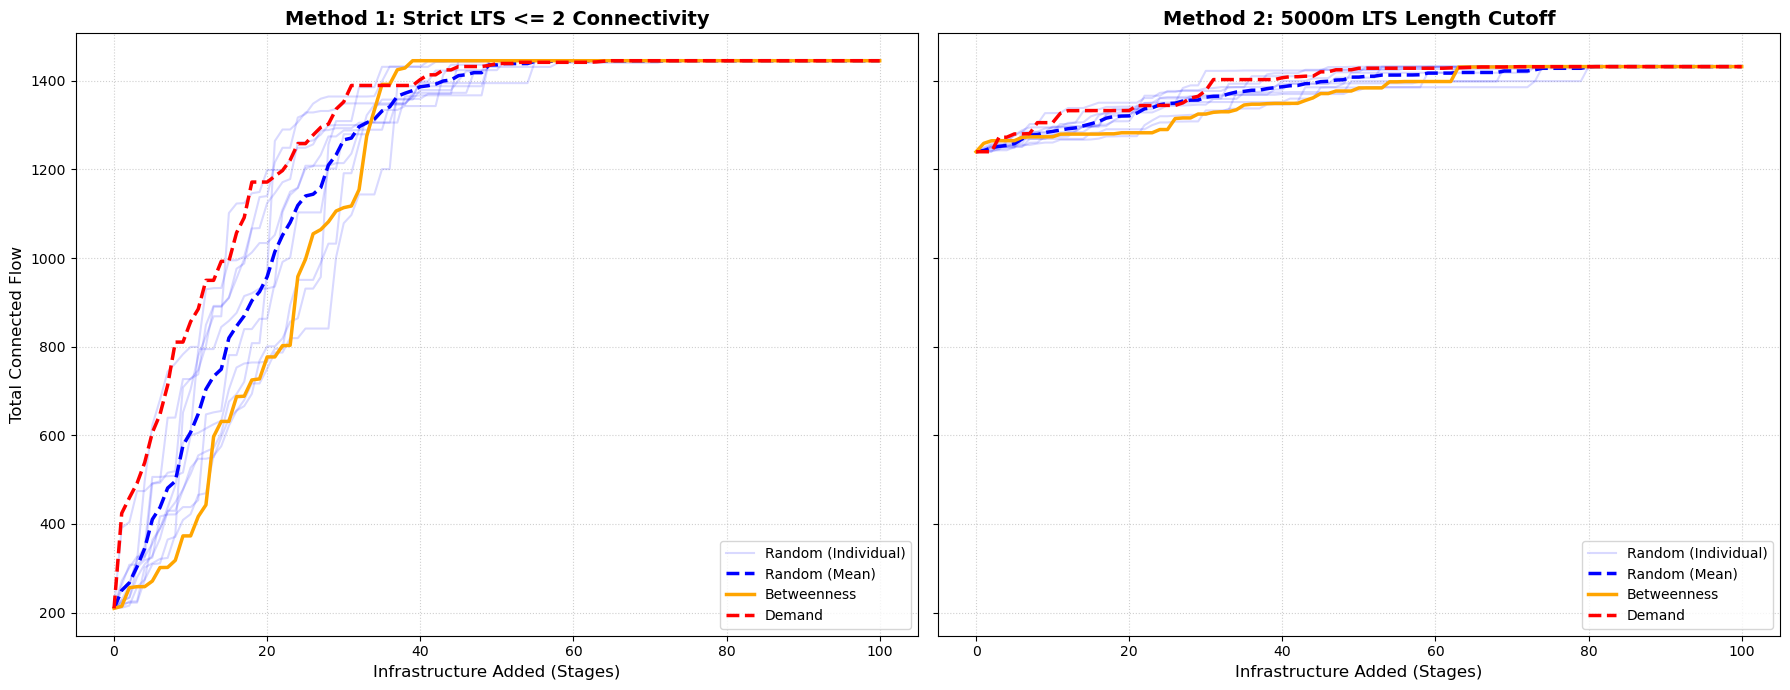

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
stages = range(len(demand_strict))


# PLOT 1
for i, r_flows in enumerate(random_strict_all):
    label = 'Random (Individual)' if i == 0 else None
    ax1.plot(stages, r_flows, color='blue', alpha=0.15, linewidth=1.5, label=label)
ax1.plot(stages, mean_random_strict, color='blue', linestyle='--', linewidth=2.5, label='Random (Mean)')
ax1.plot(stages, betweenness_strict, color='orange', linestyle='-', linewidth=2.5, label='Betweenness')
ax1.plot(stages, demand_strict, color='red', linestyle='--', linewidth=2.5, label='Demand')
ax1.plot(stages, demand_ltn_priority_strict, color='green', linestyle='--', linewidth=2.5, label='Demand LTN Priority')
ax1.plot(stages, betweeness_ltn_prioirty_strict, color='purple', linestyle='--', linewidth=2.5, label='Betweenness LTN Priority')
ax1.set_title("Method 1: Strict LTS <= 2 Connectivity", fontsize=14, fontweight='bold')
ax1.set_xlabel("Infrastructure Added (Stages)", fontsize=12)
ax1.set_ylabel("Total Connected Flow", fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right', fontsize=10)


# PLOT 2
for i, r_flows in enumerate(random_cutoff_all):
    label = 'Random (Individual)' if i == 0 else None
    ax2.plot(stages, r_flows, color='blue', alpha=0.15, linewidth=1.5, label=label)
ax2.plot(stages, mean_random_cutoff, color='blue', linestyle='--', linewidth=2.5, label='Random (Mean)')
ax2.plot(stages, betweenness_cutoff, color='orange', linestyle='-', linewidth=2.5, label='Betweenness')
ax2.plot(stages, demand_cutoff, color='red', linestyle='--', linewidth=2.5, label='Demand')
ax2.plot(stages, demand_ltn_priority_cutoff, color='green', linestyle='--', linewidth=2.5, label='Demand LTN Priority')
ax2.plot(stages, betweeness_ltn_prioirty_cutoff, color='purple', linestyle='--', linewidth=2.5, label='Betweenness LTN Priority')
ax2.set_title("Method 2: 5000m LTS Length Cutoff", fontsize=14, fontweight='bold')
ax2.set_xlabel("Infrastructure Added (Stages)", fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging\gateshead_bikeability_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# set up folder
base_debug_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging"

# Create specific folders so things stay organized
folders = {
    "strict_main": os.path.join(base_debug_dir, "Strict_LTS", "Main_Scenarios"),
    "strict_random": os.path.join(base_debug_dir, "Strict_LTS", "Random_Winners"),
}

for folder in folders.values():
    os.makedirs(folder, exist_ok=True)

# Ensure base layers are ready
target_crs = "EPSG:4326"
od_demand = od_demand.to_crs(target_crs)
G_bikeable_edges = G_bikeable_edges.to_crs(target_crs) 
ltns = ltns.to_crs(target_crs)
target_demand_total = od_demand['total_flow'].sum()


def generate_map(G_routed, G_abs, met_flow, stage, title, save_path):
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Base Map & Demand
    G_bikeable_edges.plot(ax=ax, color='lightgray', linewidth=0.5)
    od_demand.plot(ax=ax, column='total_flow', legend=False, scheme="natural_breaks", markersize=50, alpha=0.7)

    # Add Labels 
    for _, row in od_demand.iterrows():
        if row.geometry is not None:
            point = row.geometry.interpolate(0.5, normalized=True)
            ax.text(
                point.x, point.y,
                f"{row['total_flow']:.1f}",
                fontsize=5, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.1, edgecolor='none', pad=1),
                clip_on=True
            )

    # Process and Plot Routed Edges (Blue)
    # Check if edges exist to prevent Stage 0 crash
    has_routed = G_routed is not None and len(G_routed.edges) > 0
    if has_routed:
        if "crs" not in G_routed.graph:
            G_routed.graph["crs"] = "EPSG:3857"
        _, edges_routed = ox.graph_to_gdfs(G_routed)
        edges_routed = edges_routed.to_crs(target_crs)
        edges_routed.plot(ax=ax, color='blue', linewidth=1)
        
    # Process and Plot Abstract Edges (Red)
    has_abs = G_abs is not None and len(G_abs.edges) > 0
    if has_abs:
        if "crs" not in G_abs.graph:
            G_abs.graph["crs"] = "EPSG:3857"
        _, edges_abs = ox.graph_to_gdfs(G_abs)
        edges_abs = edges_abs.to_crs(target_crs)
        edges_abs.plot(ax=ax, color='red', linewidth=2)

    # Plot LTNs
    ltns.plot(ax=ax, alpha=0.5, color="orange")

    # Zoom to AOI
    if has_routed:
        minx, miny, maxx, maxy = edges_routed.total_bounds
    else:
        # If Stage 0, zoom to the overall demand area instead
        minx, miny, maxx, maxy = od_demand.total_bounds
        
    pad_x = (maxx - minx) * 0.30
    pad_y = (maxy - miny) * 0.30

    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_autoscale_on(False)
    ax.set_axis_off()

    # Title and Save
    pct_met = (met_flow / target_demand_total) * 100 if target_demand_total > 0 else 0
    plt.title(f"{title} | Stage {stage}\nFlow Met: {met_flow:.1f} of {target_demand_total:.1f} ({pct_met:.1f}%)")
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)


for stage, (G_routed, G_abs, flow) in enumerate(zip(demand_gts, demand_abs, demand_strict)):
    save_path = os.path.join(folders["strict_main"], f"Demand_Stage_{stage}.png")
    generate_map(G_routed, G_abs, flow, stage, "Demand Weighted", save_path)


for run_idx, (r_gts, r_abs, r_flows) in enumerate(zip(random_gts_list, random_abs_list, random_strict_all)):
    for stage, (G_routed, G_abs, random_flow) in enumerate(zip(r_gts, r_abs, r_flows)):
        
        # Guard against index errors
        if stage >= len(demand_strict):
            continue
            
        main_flow = demand_strict[stage]
        
        # If Random beats the main Demand run
        if random_flow > main_flow:
            print(f"Random Run {run_idx} Stage {stage} ({random_flow:.1f} vs {main_flow:.1f})")
            
            title = f"Random Run {run_idx} vs Demand ({random_flow:.1f} vs {main_flow:.1f})"
            save_path = os.path.join(folders["strict_random"], f"Run{run_idx}_Stage{stage}_Winner.png")
            
            generate_map(G_routed, G_abs, random_flow, stage, title, save_path)



In [ ]:
print("Setting up folders for distance Cutoff Method...")
cutoff_folders = {
    "cutoff_main": os.path.join(base_debug_dir, "Cutoff_5000m", "Main_Scenarios"),
    "cutoff_random": os.path.join(base_debug_dir, "Cutoff_5000m", "Random_Winners"),
}

for folder in cutoff_folders.values():
    os.makedirs(folder, exist_ok=True)


for stage, (G_routed, G_abs, flow) in enumerate(zip(demand_gts, demand_abs, demand_cutoff)):
    save_path = os.path.join(cutoff_folders["cutoff_main"], f"Demand_Cutoff_Stage_{stage}.png")
    generate_map(G_routed, G_abs, flow, stage, "Demand (5000m Cutoff)", save_path)


for run_idx, (r_gts, r_abs, r_flows) in enumerate(zip(random_gts_list, random_abs_list, random_cutoff_all)):
    for stage, (G_routed, G_abs, random_flow) in enumerate(zip(r_gts, r_abs, r_flows)):
        
        # Guard against index errors
        if stage >= len(demand_cutoff):
            continue
            
        main_flow = demand_cutoff[stage]
        
        # If Random beats the main Demand run in the Cutoff method
        if random_flow > main_flow:
            print(f" Random Run {run_idx} Stage {stage} ({random_flow:.1f} vs {main_flow:.1f})")
            
            title = f"Random {run_idx} vs Demand Cutoff\n({random_flow:.1f} vs {main_flow:.1f})"
            save_path = os.path.join(cutoff_folders["cutoff_random"], f"Run{run_idx}_Stage{stage}_Cutoff_Winner.png")
            
            # Use the exact same generate_map function from the previous cell!
            generate_map(G_routed, G_abs, random_flow, stage, title, save_path)

